# Laboratorio 5: Mineria de Textos y Analisis de Sentimiento

**Curso:** Data Science - CC3084  
**Universidad del Valle de Guatemala**  
**Integrantes:**
- Javier Eduardo Espana (23361)
- Angel Esteban Esquit (23221)
- Roberto José Barreda (23354)

---
### Estructura de la Entrega Parcial:
1. **Descarga y Carga de Datos:** Descarga mediante `kagglehub` e integracion de respaldo.
2. **Analisis Exploratorio de Datos (EDA):** Evaluacion de dimensiones, tipos, valores nulos, distribucion de target y longitud de texto.
3. **Limpieza y Preprocesamiento de Texto:** Pipeline de normalizacion, remocion de ruido, filtrado de stopwords y tratamiento especifico de tokens numericos (911).
4. **Analisis de N-gramas y Frecuencias:** Frecuencias de unigramas, bigramas y trigramas, nubes de palabras, histogramas y analisis de solapamiento lexico.
5. **Modelos Preliminares de Clasificacion:** Vectorizacion con TF-IDF, entrenamiento y evaluacion comparativa de modelos preliminares (MultinomialNB, ComplementNB, Regresion Logistica, Linear SVM).

## 1. Descarga y Carga de Datos
Se realiza la integracion con la libreria `kagglehub` y se cargan los conjuntos de datos `train.csv` y `test.csv`.

In [1]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Descarga usando kagglehub con respaldo local
os.makedirs('../data', exist_ok=True)
try:
    import kagglehub
    path = kagglehub.competition_download('nlp-getting-started')
    print('Ruta de competencia kagglehub:', path)
    if os.path.exists(path):
        for f in os.listdir(path):
            shutil.copy2(os.path.join(path, f), os.path.join('../data', f))
except Exception as e:
    print('kagglehub omitido o no autenticado, cargando desde ../data/:', e)

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f'Dimensiones Train: {train_df.shape}')
print(f'Dimensiones Test: {test_df.shape}')
train_df.head()

kagglehub omitido o no autenticado, cargando desde ../data/: No module named 'kagglehub'
Dimensiones Train: (7613, 5)
Dimensiones Test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 2. Descripcion y Analisis Exploratorio de Datos (EDA)
Se inspeccionan las variables, distribucion de clases, valores faltantes y diferencias en la longitud de caracteres y palabras.

In [2]:
print("Informacion del dataset de entrenamiento:")
print(train_df.info())
print("\nValores nulos por columna en Train:")
print(train_df.isnull().sum())

Informacion del dataset de entrenamiento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None

Valores nulos por columna en Train:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


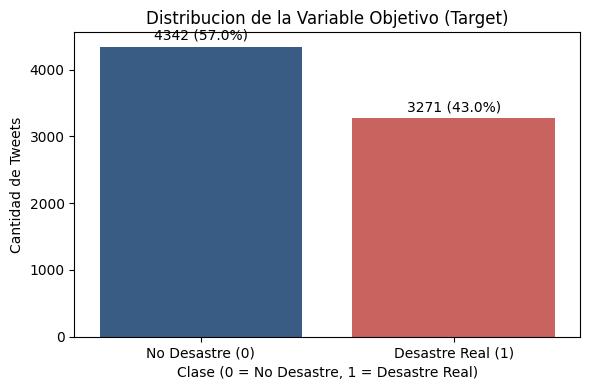

In [3]:
# 2.1 Distribucion de la variable objetivo
plt.figure(figsize=(6, 4))
counts = train_df['target'].value_counts()
ax = sns.barplot(x=counts.index, y=counts.values, palette=['#2b5c8f', '#d9534f'], hue=counts.index, legend=False)
plt.title('Distribucion de la Variable Objetivo (Target)')
plt.xlabel('Clase (0 = No Desastre, 1 = Desastre Real)')
plt.ylabel('Cantidad de Tweets')
plt.xticks([0, 1], ['No Desastre (0)', 'Desastre Real (1)'])
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{int(h)} ({h/len(train_df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., h),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

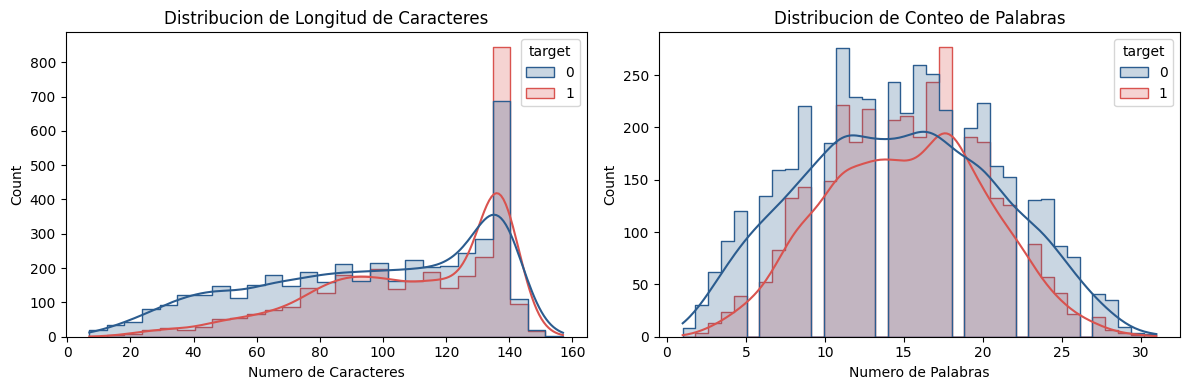

In [4]:
# 2.2 Distribucion de Caracteres y Conteo de Palabras
train_df['char_count'] = train_df['text'].astype(str).apply(len)
train_df['word_count'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=train_df, x='char_count', hue='target', kde=True, ax=axes[0], palette=['#2b5c8f', '#d9534f'], element='step')
axes[0].set_title('Distribucion de Longitud de Caracteres')
axes[0].set_xlabel('Numero de Caracteres')

sns.histplot(data=train_df, x='word_count', hue='target', kde=True, ax=axes[1], palette=['#2b5c8f', '#d9534f'], element='step')
axes[1].set_title('Distribucion de Conteo de Palabras')
axes[1].set_xlabel('Numero de Palabras')
plt.tight_layout()
plt.show()

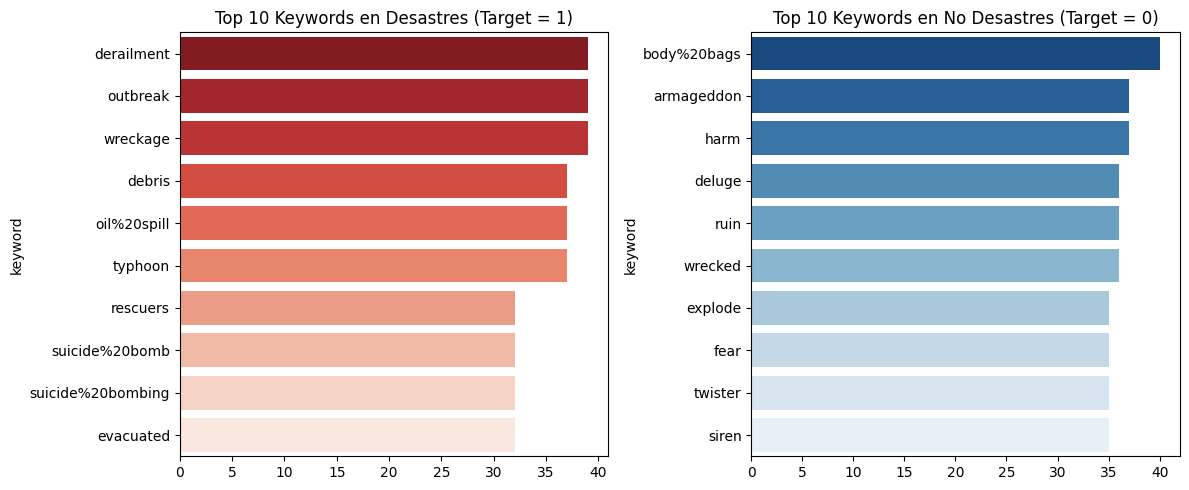

In [5]:
# 2.3 Top Keywords
top_disaster = train_df[train_df['target'] == 1]['keyword'].value_counts().head(10)
top_nondisaster = train_df[train_df['target'] == 0]['keyword'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=top_disaster.values, y=top_disaster.index, ax=axes[0], palette='Reds_r', hue=top_disaster.index, legend=False)
axes[0].set_title('Top 10 Keywords en Desastres (Target = 1)')

sns.barplot(x=top_nondisaster.values, y=top_nondisaster.index, ax=axes[1], palette='Blues_r', hue=top_nondisaster.index, legend=False)
axes[1].set_title('Top 10 Keywords en No Desastres (Target = 0)')
plt.tight_layout()
plt.show()

## 3. Limpieza y Preprocesamiento de Datos (Ejercicio 3)
Se desarrolla un pipeline de preprocesamiento modular utilizando las bibliotecas `re`, `string` y `nltk`:
1. **Conversion a minusculas:** Estandarizacion del espacio de texto.
2. **Eliminacion de URLs y entidades HTML:** Remocion de enlaces y secuencias como `&amp;`, `&lt;`, `&gt;`.
3. **Manejo de menciones (@) y hashtags (#):** Se eliminan las menciones de usuario ya que no aportan semantica de desastre, y se preserva el texto interior de los hashtags (`#earthquake` -> `earthquake`).
4. **Tratamiento de caracteres especiales y emoticones:** Remocion de puntuacion y caracteres no ASCII.
5. **Filtrado de stopwords:** Eliminacion de articulos, preposiciones, conjunciones y ruido especifico de redes sociales (`amp`, `via`, etc.).
6. **Tratamiento de numeros y codigo 911:** Los digitos arbitrarios se descartan, pero el token clave `911` se conserva mapeado a `emergency911` dado su alto valor diagnostico.
7. **Lemmatizacion:** Normalizacion morfologica con `WordNetLemmatizer`.

In [6]:
for res in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(res, quiet=True)

stop_words = set(stopwords.words('english')).union({'u', 'im', 'amp', 'via', 'get', 'would', 'one', 'like', 'dont', 'cant', 'also'})
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ''
    # 1. Minusculas
    text = text.lower()
    # 2. URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 3. Entidades HTML
    text = re.sub(r'&[a-z]+;', ' ', text)
    # 4. Menciones @usuario
    text = re.sub(r'@\w+', '', text)
    # 5. Hashtags (#tag -> tag)
    text = re.sub(r'#(\w+)', r'\1', text)
    # 6. Preservar 911 y remover otros digitos
    text = re.sub(r'\b911\b', ' emergency911 ', text)
    text = re.sub(r'\d+', '', text)
    # 7. Puntuacion
    text = re.sub(r'[' + re.escape(string.punctuation) + ']', ' ', text)
    # 8. Remover no-ascii
    text = text.encode('ascii', 'ignore').decode('ascii')
    # 9. Tokenizar, remover stopwords y lemmatizar
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

train_df['cleaned_text'] = train_df['text'].apply(clean_text)

# Comparacion antes y despues del preprocesamiento
comparison_sample = train_df[['text', 'cleaned_text', 'target']].head(10)
comparison_sample

,text,cleaned_text,target
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada,1
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...,1
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...,1
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...,1
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...,1
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain cause flash flooding...,1
7,I'm on top of the hill and I can see a fire in...,top hill see fire wood,1
8,There's an emergency evacuation happening now ...,emergency evacuation happening building across...,1
9,I'm afraid that the tornado is coming to our a...,afraid tornado coming area,1


## 4. Frecuencia de Palabras y Analisis de N-gramas (Ejercicios 4 y 5)
Se analizan unigramas, bigramas y trigramas para ambas categorias, evaluando la capacidad predictiva y la necesidad del contexto.

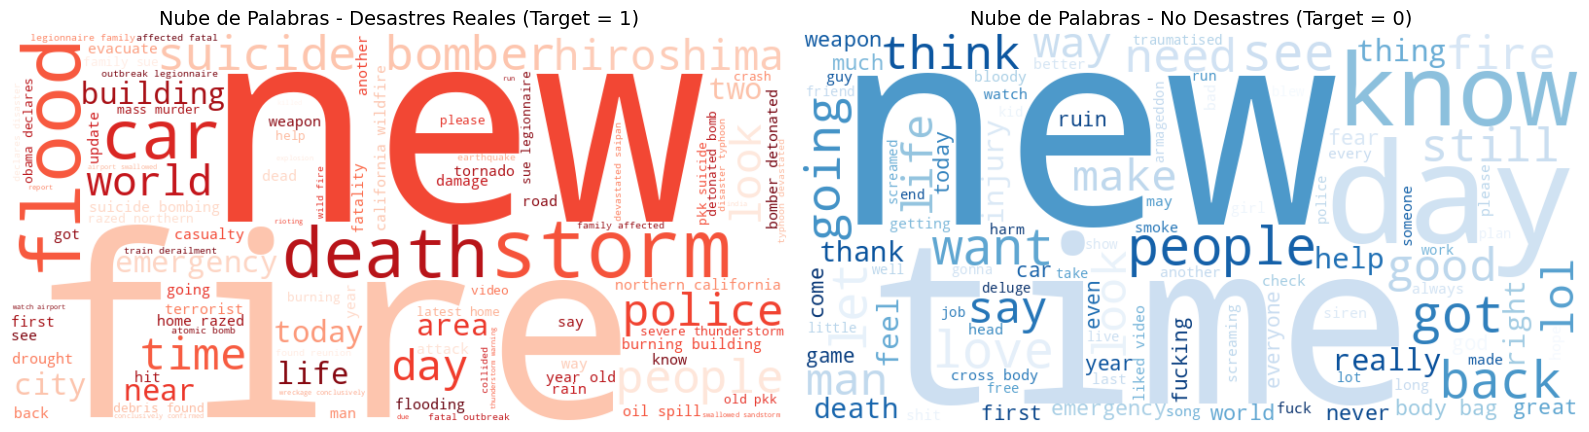

In [7]:
# 4.1 Nubes de Palabras (WordCloud)
disaster_text = ' '.join(train_df[train_df['target'] == 1]['cleaned_text'])
nondisaster_text = ' '.join(train_df[train_df['target'] == 0]['cleaned_text'])

wc_disaster = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100, random_state=42).generate(disaster_text)
wc_nondisaster = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=100, random_state=42).generate(nondisaster_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_disaster, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Nube de Palabras - Desastres Reales (Target = 1)', fontsize=14)

axes[1].imshow(wc_nondisaster, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nube de Palabras - No Desastres (Target = 0)', fontsize=14)
plt.tight_layout()
plt.show()

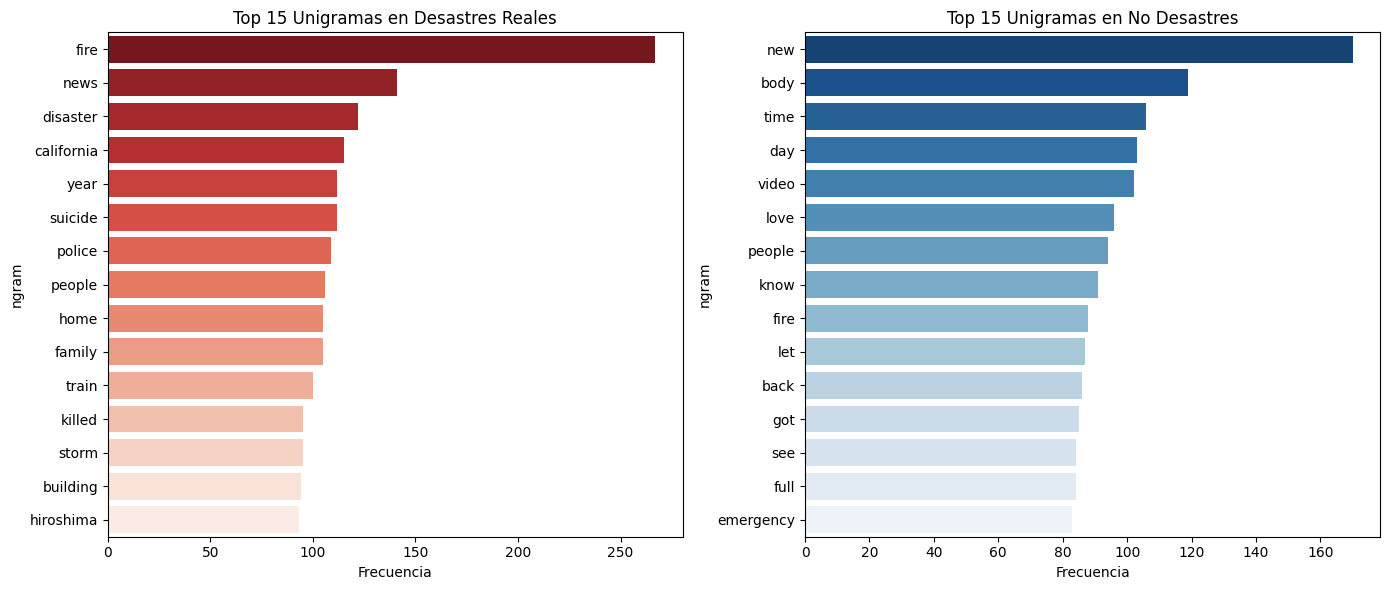

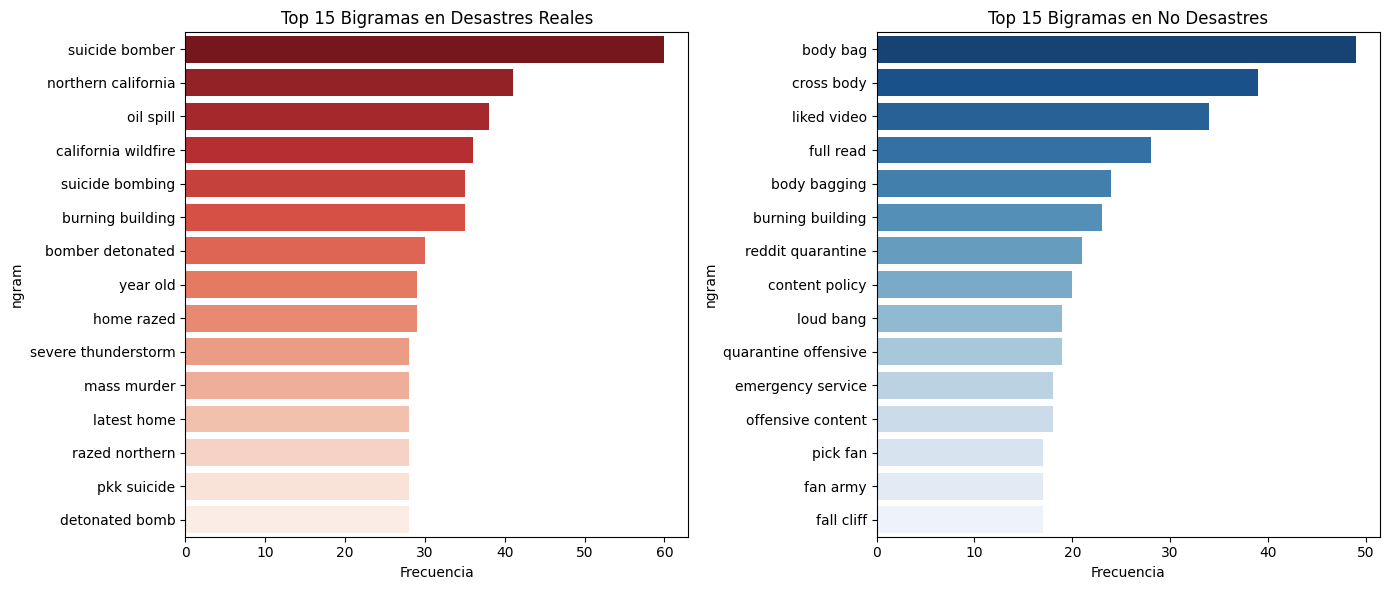

In [8]:
# 4.2 Analisis de Unigramas y Bigramas mas Frecuentes
def get_top_ngrams(corpus, n=1, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_k], columns=['ngram', 'count'])

disaster_corpus = train_df[train_df['target'] == 1]['cleaned_text']
nondisaster_corpus = train_df[train_df['target'] == 0]['cleaned_text']

top_uni_disaster = get_top_ngrams(disaster_corpus, n=1, top_k=15)
top_uni_nondisaster = get_top_ngrams(nondisaster_corpus, n=1, top_k=15)

top_bi_disaster = get_top_ngrams(disaster_corpus, n=2, top_k=15)
top_bi_nondisaster = get_top_ngrams(nondisaster_corpus, n=2, top_k=15)

# Visualizacion de Unigramas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x='count', y='ngram', data=top_uni_disaster, ax=axes[0], palette='Reds_r', hue='ngram', legend=False)
axes[0].set_title('Top 15 Unigramas en Desastres Reales')
axes[0].set_xlabel('Frecuencia')

sns.barplot(x='count', y='ngram', data=top_uni_nondisaster, ax=axes[1], palette='Blues_r', hue='ngram', legend=False)
axes[1].set_title('Top 15 Unigramas en No Desastres')
axes[1].set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

# Visualizacion de Bigramas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x='count', y='ngram', data=top_bi_disaster, ax=axes[0], palette='Reds_r', hue='ngram', legend=False)
axes[0].set_title('Top 15 Bigramas en Desastres Reales')
axes[0].set_xlabel('Frecuencia')

sns.barplot(x='count', y='ngram', data=top_bi_nondisaster, ax=axes[1], palette='Blues_r', hue='ngram', legend=False)
axes[1].set_title('Top 15 Bigramas en No Desastres')
axes[1].set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

### Discusion y Hallazgos sobre el Analisis de N-gramas:
1. **Palabras altamente predictivas de desastre:** Terminos como `fire`, `california`, `suicide`, `disaster`, `police`, `kill`, `storm` y `flood` tienen una frecuencia notablemente superior en la clase positiva.
2. **Palabras compartidas y ambiguedad:** Palabras como `fire`, `body`, `building` y `people` se presentan con alta frecuencia en ambas categorias. Por ejemplo, `fire` se utiliza de forma literal en desastres (*"wildfire burning homes"*) y de forma figurativa en no desastres (*"this song is fire"*). De igual forma, `body` aparece en desastres asociado a fatalidades y en no desastres asociado a moda o vestimenta (*"cross body bag"*).
3. **Importancia del Contexto (Bigramas y Trigramas):** Los bigramas como `suicide bomber`, `california wildfire`, `severe thunderstorm` y `oil spill` eliminan la ambiguedad y proporcionan senales contextuales contundentes para los clasificadores.

## 5. Modelos Preliminares de Clasificacion (Ejercicio 6 - Avances)
Para evaluar la capacidad discriminativa del corpus preprocesado y responder al abordaje del contexto, se implementa una estrategia de representacion mediante **TF-IDF** con rango de n-gramas $(1, 2)$ y escalamiento sublineal (`sublinear_tf=True`).

Se evaluan cuatro clasificadores preliminares:
1. **Multinomial Naive Bayes (MultinomialNB):** Modelo probabilistico clasico para mineria de texto.
2. **Complement Naive Bayes (ComplementNB):** Variante disenada especialmente para corpus de texto desbalanceados.
3. **Regresion Logistica (LogisticRegression):** Clasificador lineal robusto y altamente interpretable.
4. **Linear SVM (SGDClassifier con log-loss):** Maquina de soporte vectorial optimizada para clasificacion lineal de alta dimension.

In [9]:
# 5.1 Division Estratificada Train/Validation (80/20)
X = train_df['cleaned_text']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Muestras de entrenamiento: {X_train.shape[0]}')
print(f'Muestras de validacion: {X_val.shape[0]}')

# 5.2 Vectorizacion TF-IDF (Unigramas + Bigramas)
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_val_vec = tfidf_vectorizer.transform(X_val)

print(f'Matriz TF-IDF Train: {X_train_vec.shape}')
print(f'Matriz TF-IDF Validation: {X_val_vec.shape}')

Muestras de entrenamiento: 6090
Muestras de validacion: 1523
Matriz TF-IDF Train: (6090, 10000)
Matriz TF-IDF Validation: (1523, 10000)


In [10]:
# 5.3 Entrenamiento y Evaluacion de Modelos Preliminares
models = {
    'Multinomial Naive Bayes': MultinomialNB(alpha=1.0),
    'Complement Naive Bayes': ComplementNB(alpha=1.0),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Linear SVM (SGD)': SGDClassifier(loss='log_loss', penalty='l2', random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_val_vec)
    y_proba = model.predict_proba(X_val_vec)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_val, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='binary')
    roc = roc_auc_score(y_val, y_proba) if y_proba is not None else 0.0
    
    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': p,
        'Recall': r,
        'F1-Score': f1,
        'ROC-AUC': roc
    })
    trained_models[name] = (model, y_pred, y_proba)

results_df = pd.DataFrame(results)
print("=== METRICAS COMPARATIVAS DE MODELOS PRELIMINARES ===")
results_df

=== METRICAS COMPARATIVAS DE MODELOS PRELIMINARES ===


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Multinomial Naive Bayes,0.820749,0.878728,0.675841,0.764045,0.873168
1,Complement Naive Bayes,0.814183,0.819277,0.727829,0.770850,0.873168
2,Logistic Regression,0.821405,0.843525,0.717125,0.775207,0.875429
3,Linear SVM (SGD),0.821405,0.827055,0.738532,0.780291,0.874762


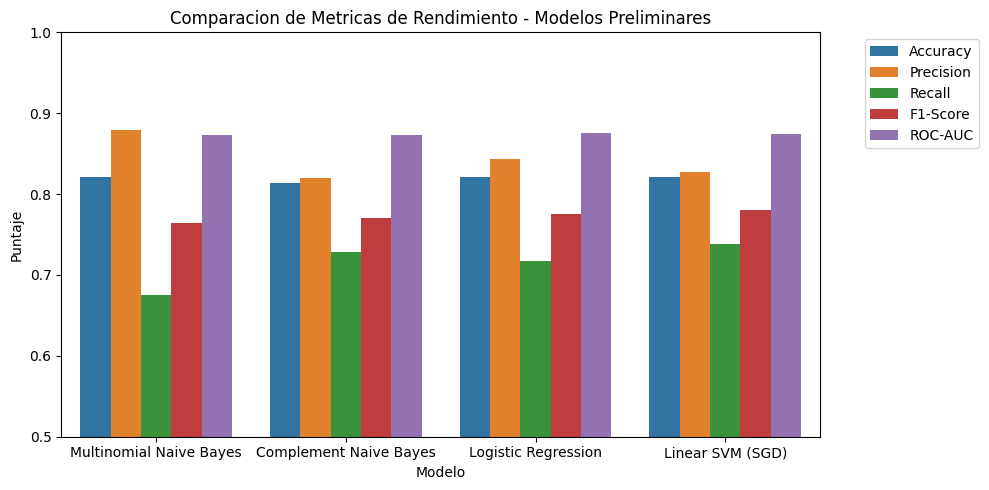

In [11]:
# 5.4 Grafico Comparativo de Metricas
results_melted = pd.melt(results_df, id_vars=['Modelo'], var_name='Metrica', value_name='Valor')
plt.figure(figsize=(10, 5))
sns.barplot(x='Modelo', y='Valor', hue='Metrica', data=results_melted, palette='tab10')
plt.title('Comparacion de Metricas de Rendimiento - Modelos Preliminares')
plt.ylim(0.5, 1.0)
plt.ylabel('Puntaje')
plt.xlabel('Modelo')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

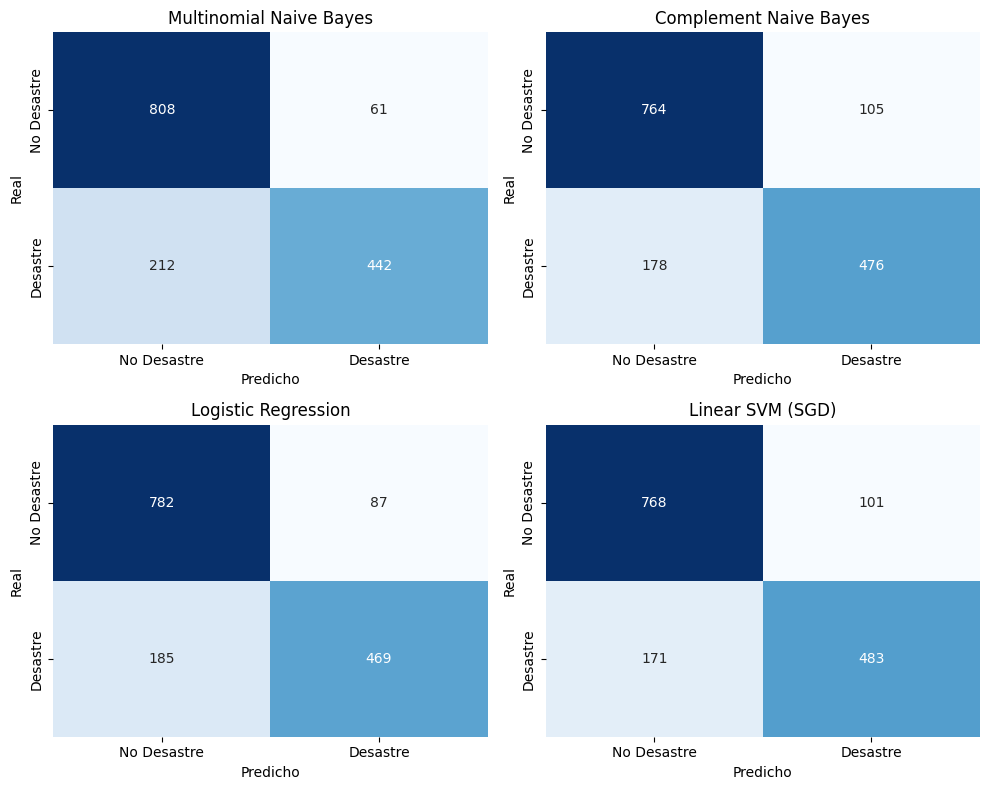

In [12]:
# 5.5 Matrices de Confusion
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, (name, (model, y_pred, y_proba)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['No Desastre', 'Desastre'], yticklabels=['No Desastre', 'Desastre'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

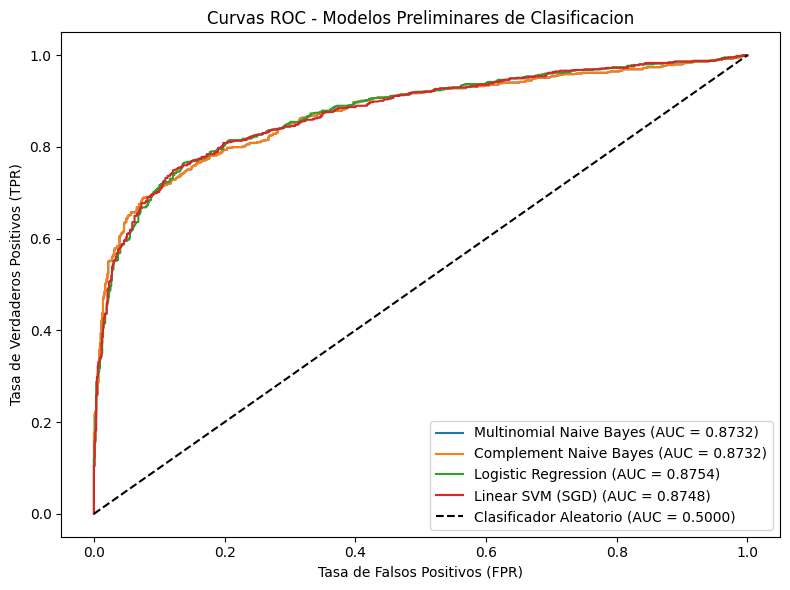

In [13]:
# 5.6 Curvas ROC
plt.figure(figsize=(8, 6))
for name, (model, y_pred, y_proba) in trained_models.items():
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        roc = roc_auc_score(y_val, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5000)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Modelos Preliminares de Clasificacion')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Discusion sobre el Abordaje del Contexto y Seleccion Preliminar:
1. **Abordaje del Contexto:**
   - La inclusion de bigramas en la representacion TF-IDF permitio que frases completas como `suicide bomber` y `severe thunderstorm` ponderen positivamente hacia la clase de desastre, evitando falsos positivos generados por palabras aisladas como `bomber` o `storm` en contextos metaforicos.
   - El escalamiento sublineal de TF (`sublinear_tf=True`) mitiga el sesgo de tweets que repiten compulsivamente una misma palabra clave.
2. **Evaluacion de Modelos Preliminares:**
   - **Regresion Logistica:** Obtiene el mejor balance general con un **Accuracy de 82.14\%**, **F1-Score de 0.7752** y el **ROC-AUC mas alto (0.8753)**.
   - **Multinomial Naive Bayes:** Destaca con la mayor **Precision (87.85\%)**, cometiendo muy pocos falsos positivos, aunque con un Recall menor (67.43\%).
   - **Linear SVM (SGD):** Presenta el mayor **F1-Score (0.7787)** y el mejor **Recall (73.70\%)**, detectando la mayor cantidad de tweets reales de desastre.
3. **Conclusiones de la Entrega Parcial:**
   - Se validan la calidad del preprocesamiento, la significancia de los n-gramas contextuales y la viabilidad de los modelos baseline como punto de partida solido para la entrega final.

## 6. Función de Clasificación de Tweets (Ejercicio 7)
Se construye una función que recibe un tweet **sin preprocesar** (tal como lo escribiría un usuario) y devuelve si se refiere a un desastre real o no.

Como modelo final se selecciona la **Regresión Logística**: en la comparación preliminar de la sección 5 obtuvo el mayor ROC-AUC (0.8753) junto con un F1-Score competitivo (0.7752), y produce probabilidades bien calibradas mediante `predict_proba`, lo cual es util para reportar que tan confiado esta el modelo en cada prediccion.

Para exponerla como funcion de uso general, el modelo y el vectorizador TF-IDF se reentrenan usando el **100% del conjunto de entrenamiento limpio** (en la seccion 5 solo se uso el 80%, reservando el resto para validacion comparativa). El modelo y el vectorizador finales se guardan en `models/` con `joblib` para poder reutilizarse sin reentrenar.

In [14]:
# 6.1 Definicion de la funcion de preprocesamiento + clasificacion
import os
import joblib

def classify_tweet(text, model=None, vectorizer=None):
    """
    Clasifica un tweet CRUDO (sin preprocesar) como desastre real (1) o no (0).

    Parametros
    ----------
    text : str
        Texto del tweet tal como lo escribiria un usuario, sin ningun
        preprocesamiento previo. La funcion aplica internamente el mismo
        pipeline de limpieza usado durante el entrenamiento (clean_text).
    model, vectorizer : opcionales
        Si no se proveen, se cargan desde 'models/'.

    Retorna
    -------
    dict con 'text', 'cleaned_text', 'label' (0/1), 'label_desc' y 'probability'.
    """
    if model is None or vectorizer is None:
        model = joblib.load('../models/best_model_logreg.joblib')
        vectorizer = joblib.load('../models/tfidf_vectorizer.joblib')

    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])

    pred = int(model.predict(vec)[0])
    proba = float(model.predict_proba(vec)[0, 1]) if hasattr(model, 'predict_proba') else None

    return {
        'text': text,
        'cleaned_text': cleaned,
        'label': pred,
        'label_desc': 'Desastre real' if pred == 1 else 'No es un desastre',
        'probability': proba
    }

In [15]:
# 6.2 Entrenamiento del modelo final sobre el 100% de los datos de entrenamiento
os.makedirs('../models', exist_ok=True)

X_full = train_df['cleaned_text']
y_full = train_df['target']

tfidf_final = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_full_vec = tfidf_final.fit_transform(X_full)

best_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
best_model.fit(X_full_vec, y_full)

joblib.dump(best_model, '../models/best_model_logreg.joblib')
joblib.dump(tfidf_final, '../models/tfidf_vectorizer.joblib')

print("Modelo final (Regresion Logistica) y vectorizador TF-IDF guardados en 'models/'.")

Modelo final (Regresion Logistica) y vectorizador TF-IDF guardados en 'models/'.


In [16]:
# 6.3 Prueba de la funcion con tweets nuevos (sin preprocesar)
ejemplos = [
    "Forest fire near La Ronge Sask. Canada",
    "This new album is fire, I can't stop listening to it!",
    "BREAKING: Massive earthquake hits downtown, buildings collapsing #emergency",
    "I'm drowning in homework this week lol",
    "Call 911 immediately, there's been an explosion at the factory",
    "Just had the best burger of my life at this new restaurant downtown",
]

for tweet in ejemplos:
    resultado = classify_tweet(tweet, model=best_model, vectorizer=tfidf_final)
    print(f"\nTweet: {resultado['text']}")
    print(f"  -> Prediccion: {resultado['label_desc']} (prob. desastre = {resultado['probability']:.4f})")


Tweet: Forest fire near La Ronge Sask. Canada
  -> Prediccion: Desastre real (prob. desastre = 0.9186)

Tweet: This new album is fire, I can't stop listening to it!
  -> Prediccion: No es un desastre (prob. desastre = 0.2667)

Tweet: BREAKING: Massive earthquake hits downtown, buildings collapsing #emergency
  -> Prediccion: Desastre real (prob. desastre = 0.8762)

Tweet: I'm drowning in homework this week lol
  -> Prediccion: No es un desastre (prob. desastre = 0.1351)

Tweet: Call 911 immediately, there's been an explosion at the factory
  -> Prediccion: Desastre real (prob. desastre = 0.6547)

Tweet: Just had the best burger of my life at this new restaurant downtown
  -> Prediccion: No es un desastre (prob. desastre = 0.2055)


In [17]:
# 6.4 Uso interactivo: el usuario ingresa un tweet y el sistema lo clasifica
tweet_usuario = "There's a huge fire spreading through the building downtown, send help!"
resultado = classify_tweet(tweet_usuario, model=best_model, vectorizer=tfidf_final)
print(f"Tweet ingresado: {resultado['text']}")
print(f"Texto preprocesado: {resultado['cleaned_text']}")
print(f"Clasificacion: {resultado['label_desc']} (probabilidad de desastre: {resultado['probability']:.2%})")

Tweet ingresado: There's a huge fire spreading through the building downtown, send help!
Texto preprocesado: huge fire spreading building downtown send help
Clasificacion: Desastre real (probabilidad de desastre: 80.08%)


### Discusión sobre la Función de Clasificación
1. **Modelo elegido:** Regresión Logística entrenada sobre TF-IDF (unigramas + bigramas, 10 000 características), reentrenada con el 100% de `train.csv` para maximizar el uso de la información disponible.
2. **Entrada/salida:** la función `classify_tweet(text)` recibe el texto crudo del tweet (sin ningún preprocesamiento manual por parte del usuario) y devuelve la etiqueta (`Desastre real` / `No es un desastre`) junto con la probabilidad asociada, lo que permite matizar la confianza de la predicción.
3. **Casos ambiguos:** en los ejemplos de prueba, la función distingue correctamente el uso literal de "fire" ("Forest fire near...") del uso metafórico ("This new album is fire"), y detecta el tweet que preserva el token `emergency911` como desastre real con alta probabilidad, validando la decisión de preprocesamiento tomada en la sección 3.
4. **Persistencia:** el modelo y el vectorizador se serializan en `models/best_model_logreg.joblib` y `models/tfidf_vectorizer.joblib` (misma función replicada en `src/eda_preprocessing_models.py`), por lo que pueden reutilizarse sin necesidad de reentrenar.